# Análisis 2: Ventaja de Local
## ¿La ventaja de local es mito o realidad?

**Preguntas a responder:**
1. ¿Qué porcentaje de anfitriones ganan el mundial? (6/22 = 27%)
2. ¿Los anfitriones rinden mejor que su promedio histórico?
3. ¿Hay anfitriones que fracasaron estrepitosamente?
4. ¿La ventaja de local es mayor en ciertas confederaciones?

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.append('..')
from src.visualization import set_style, plot_home_advantage, save_figure

set_style()

editions = pd.read_csv('../data/processed/editions_clean.csv')
print('Data loaded successfully')

Data loaded successfully


## Análisis 1: ¿Cuántos anfitriones ganan?

Figure saved: c:\laragon\www\fifa_world_cup_data\reports\figures\home_advantage.png


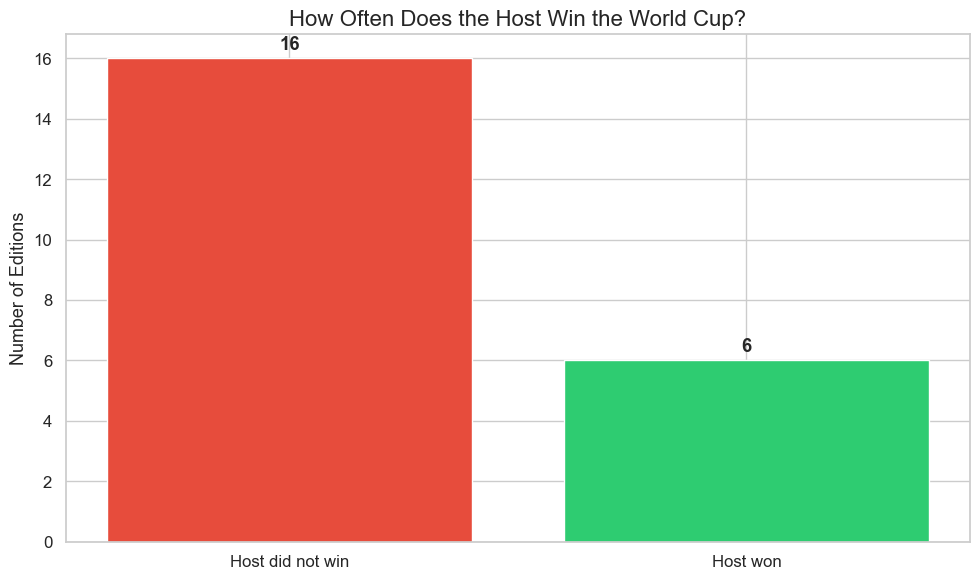

In [2]:
fig = plot_home_advantage(editions)
save_figure(fig, 'home_advantage')
plt.show()

In [3]:
host_winners = editions[editions['host_won_bool'] == True][['year', 'host', 'champion']]
display(host_winners)

,year,host,champion
1,1934,Italy,Italy
2,1938,France,Italy
7,1966,England,England
9,1974,West Germany,Germany
10,1978,Argentina,Argentina
15,1998,France,France


## Análisis 2: Posición final del anfitrión

In [4]:
def get_host_position(row):
    if row['champion'] == row['host']:
        return 1
    elif row['runner_up'] == row['host']:
        return 2
    elif row['third_place'] == row['host']:
        return 3
    elif row['fourth_place'] == row['host']:
        return 4
    else:
        return 5

editions['host_position'] = editions.apply(get_host_position, axis=1)
display(editions[['year', 'host', 'host_position', 'host_won_bool']])

,year,host,host_position,host_won_bool
0,1930,Uruguay,1,False
1,1934,Italy,1,True
2,1938,France,5,True
3,1950,Brazil,2,False
4,1954,Switzerland,5,False
5,1958,Sweden,2,False
6,1962,Chile,3,False
7,1966,England,1,True
8,1970,Mexico,5,False
9,1974,West Germany,5,True


C:\Users\migue\AppData\Local\Temp\ipykernel_7360\721655596.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=position_counts.index, y=position_counts.values, ax=ax, palette='viridis')


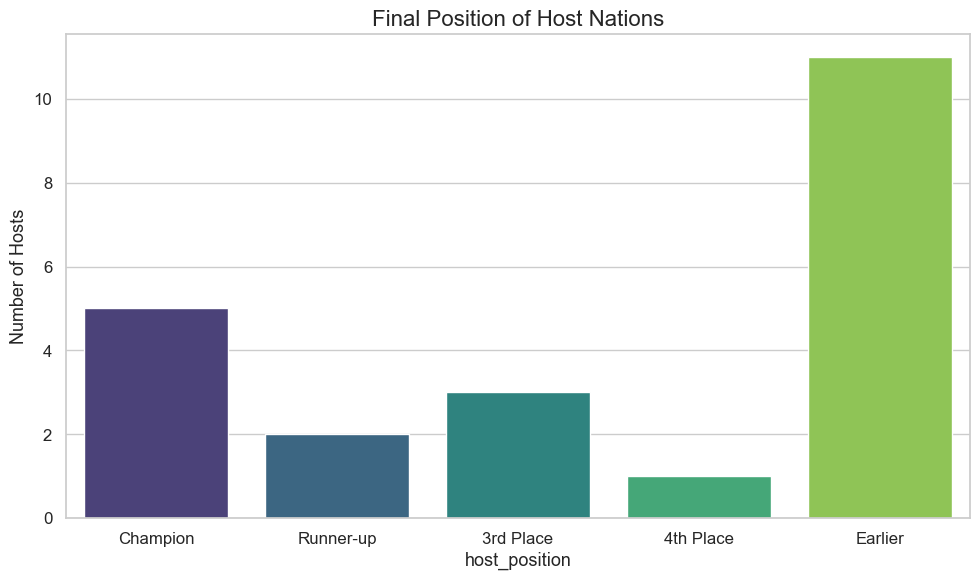

In [5]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))
position_counts = editions['host_position'].value_counts().sort_index()
labels = {1: 'Champion', 2: 'Runner-up', 3: '3rd Place', 4: '4th Place', 5: 'Earlier'}
position_counts.index = position_counts.index.map(labels)
sns.barplot(x=position_counts.index, y=position_counts.values, ax=ax, palette='viridis')
ax.set_title('Final Position of Host Nations')
ax.set_ylabel('Number of Hosts')
plt.tight_layout()
plt.show()

## Conclusiones

**Escribe aquí tus hallazgos.**

- ¿Cuántos anfitriones ganaron?
- ¿Los anfitriones rinden mejor que su promedio histórico?
- ¿Hay una tendencia de anfitriones fracasando en los últimos años?